Training Images: (50000, 32, 32, 3)
Training Labels: (50000, 1)
Testing Images: (10000, 32, 32, 3)
Testing Labels: (10000, 1)


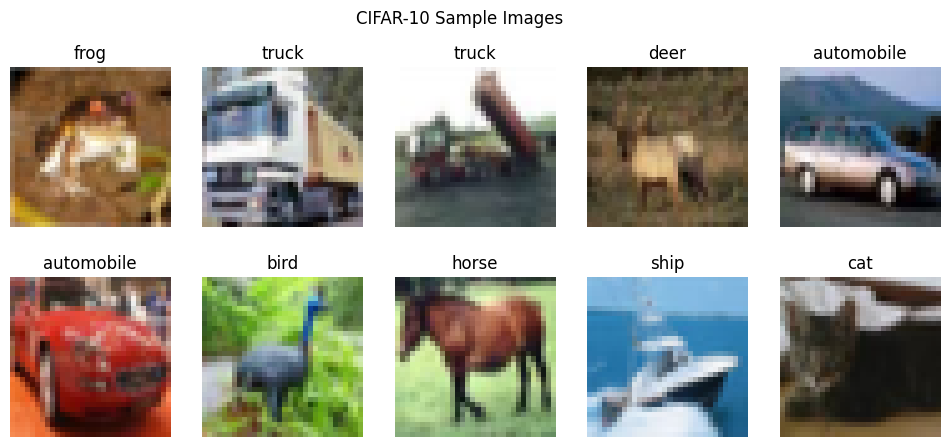

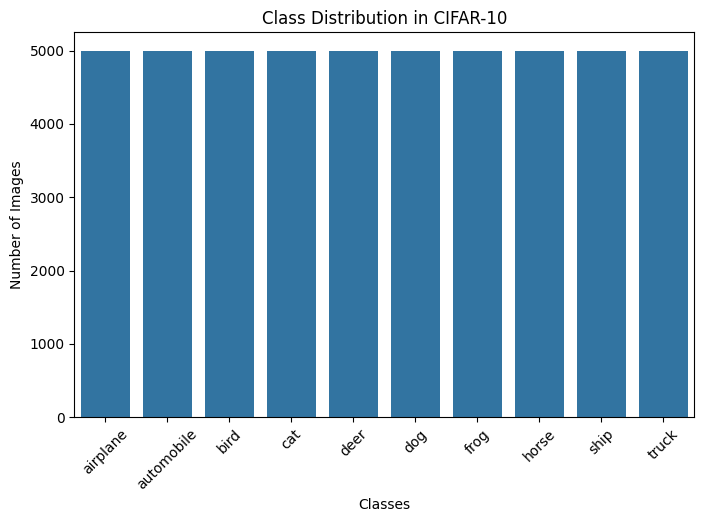

In [ ]:
# ============================
# TASK4 1: CIFAR-10 Dataset
# ============================

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load CIFAR-10
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Class names
class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

print("Training Images:", X_train.shape)
print("Training Labels:", y_train.shape)
print("Testing Images:", X_test.shape)
print("Testing Labels:", y_test.shape)


# Normalize images
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0


# ----------------------------
# Display 10 Sample Images
# ----------------------------

plt.figure(figsize=(12,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")

plt.suptitle("CIFAR-10 Sample Images")
plt.show()


# ----------------------------
# Class Distribution
# ----------------------------

plt.figure(figsize=(8,5))

sns.countplot(
    x=y_train.flatten()
)

plt.xticks(
    range(10),
    class_names,
    rotation=45
)

plt.title("Class Distribution in CIFAR-10")
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.show()

In [ ]:
# ============================
# TASK 2: Different Kernels
# ============================

from tensorflow.keras.layers import Conv2D
from tensorflow.keras.models import Sequential


kernel_sizes = [3,5,7]


for k in kernel_sizes:

    model = Sequential([
        Conv2D(
            filters=16,
            kernel_size=(k,k),
            activation='relu',
            input_shape=(32,32,3)
        )
    ])

    output_shape = model.output_shape

    print(
        f"Kernel Size {k}x{k} --> Feature Map Size:",
        output_shape
    )

Kernel Size 3x3 --> Feature Map Size: (None, 30, 30, 16)
Kernel Size 5x5 --> Feature Map Size: (None, 28, 28, 16)
Kernel Size 7x7 --> Feature Map Size: (None, 26, 26, 16)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# ============================
# TASK 3: Stride and Padding
# ============================


configs = [
    (1,"valid"),
    (2,"valid"),
    (1,"same"),
    (2,"same")
]


for stride,padding in configs:

    model = Sequential([
        Conv2D(
            filters=16,
            kernel_size=(3,3),
            strides=stride,
            padding=padding,
            activation="relu",
            input_shape=(32,32,3)
        )
    ])

    print(
        "Stride:",
        stride,
        "Padding:",
        padding,
        "Output:",
        model.output_shape
    )

Stride: 1 Padding: valid Output: (None, 30, 30, 16)
Stride: 2 Padding: valid Output: (None, 15, 15, 16)
Stride: 1 Padding: same Output: (None, 32, 32, 16)
Stride: 2 Padding: same Output: (None, 16, 16, 16)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
Feature Map Shape: (1, 30, 30, 16)


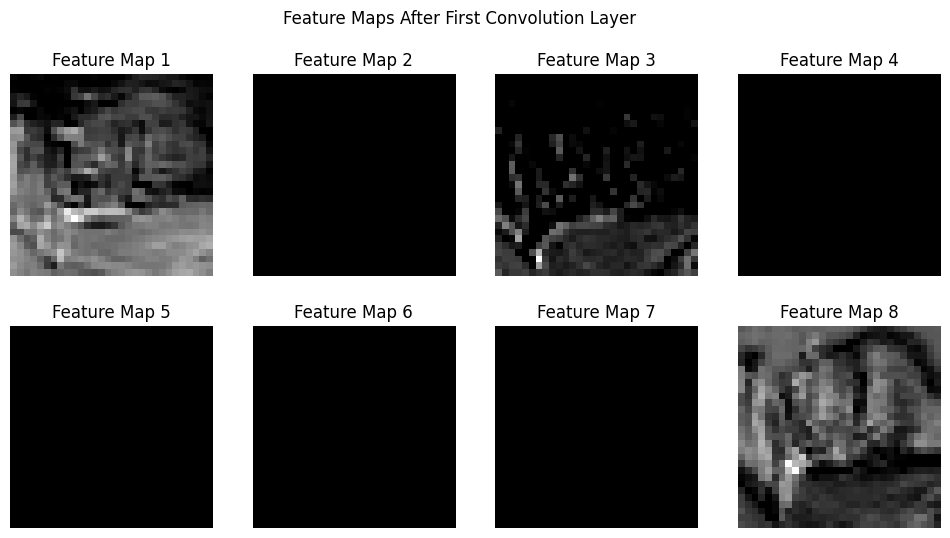

In [ ]:
# ============================
# TASK 4: FEATURE MAP VISUALIZATION
# ============================

from tensorflow.keras.models import Model
import numpy as np
import matplotlib.pyplot as plt


# Create dummy input to initialize graph
dummy_input = np.zeros((1,32,32,3))

feature_cnn(dummy_input)


# Create feature extractor model

feature_model = Model(
    inputs=feature_cnn.inputs,
    outputs=feature_cnn.layers[0].output
)


# Take one CIFAR-10 image

image = X_test[0]

image_input = np.expand_dims(
    image,
    axis=0
)


# Get feature maps

feature_maps = feature_model.predict(image_input)


print("Feature Map Shape:", feature_maps.shape)


# Display 8 feature maps

plt.figure(figsize=(12,6))

for i in range(8):

    plt.subplot(2,4,i+1)

    plt.imshow(
        feature_maps[0,:,:,i],
        cmap="gray"
    )

    plt.title(
        f"Feature Map {i+1}"
    )

    plt.axis("off")


plt.suptitle(
    "Feature Maps After First Convolution Layer"
)

plt.show()

Original Image Shape: (1, 32, 32, 3)
Max Pooling Output: (1, 16, 16, 3)
Average Pooling Output: (1, 16, 16, 3)


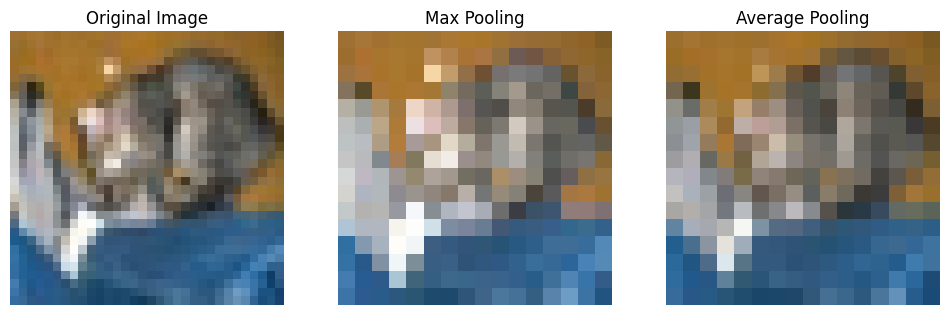

In [ ]:
# ============================
# TASK 5: MAX POOLING VS AVERAGE POOLING
# ============================

import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np


# Take one CIFAR-10 image

image = X_test[0]

image_input = np.expand_dims(image, axis=0)


# Define pooling layers

max_pool = tf.keras.layers.MaxPooling2D(
    pool_size=(2,2)
)

avg_pool = tf.keras.layers.AveragePooling2D(
    pool_size=(2,2)
)


# Apply pooling

max_output = max_pool(image_input)

avg_output = avg_pool(image_input)


print("Original Image Shape:", image_input.shape)
print("Max Pooling Output:", max_output.shape)
print("Average Pooling Output:", avg_output.shape)



# Visualization

plt.figure(figsize=(12,4))


plt.subplot(1,3,1)
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")


plt.subplot(1,3,2)
plt.imshow(max_output[0])
plt.title("Max Pooling")
plt.axis("off")


plt.subplot(1,3,3)
plt.imshow(avg_output[0])
plt.title("Average Pooling")
plt.axis("off")


plt.show()

In [ ]:
# ============================
# TASK 6: CNN MODEL
# ============================

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)


cnn_model = Sequential([

    # First Convolution
    Conv2D(
        16,
        (3,3),
        activation='relu',
        input_shape=(32,32,3)
    ),

    MaxPooling2D(
        (2,2)
    ),


    # Second Convolution
    Conv2D(
        32,
        (3,3),
        activation='relu'
    ),

    MaxPooling2D(
        (2,2)
    ),


    # Fully Connected Layer
    Flatten(),

    Dense(
        128,
        activation='relu'
    ),

    Dense(
        10,
        activation='softmax'
    )
])


# Model summary

cnn_model.summary()



# Compile

cnn_model.compile(

    optimizer='adam',

    loss='sparse_categorical_crossentropy',

    metrics=['accuracy']

)



# Train

history = cnn_model.fit(

    X_train,
    y_train,

    epochs=20,

    batch_size=32,

    validation_split=0.2

)

Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_20 (Conv2D)              │ (None, 30, 30, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 15, 15, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 13, 13, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 153,962 (601.41 KB)

 Trainable params: 153,962 (601.41 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 20s 15ms/step - accuracy: 0.4478 - loss: 1.5309 - val_accuracy: 0.5435 - val_loss: 1.2965
Epoch 2/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 18s 14ms/step - accuracy: 0.5786 - loss: 1.1949 - val_accuracy: 0.5914 - val_loss: 1.1621
Epoch 3/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 19s 15ms/step - accuracy: 0.6302 - loss: 1.0622 - val_accuracy: 0.6362 - val_loss: 1.0352
Epoch 4/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 20s 15ms/step - accuracy: 0.6606 - loss: 0.9734 - val_accuracy: 0.6354 - val_loss: 1.0486
Epoch 5/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 18s 14ms/step - accuracy: 0.6855 - loss: 0.8987 - val_accuracy: 0.6493 - val_loss: 1.0078
Epoch 6/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 18s 15ms/step - accuracy: 0.7036 - loss: 0.8365 - val_accuracy: 0.6585 - val_loss: 0.9848
Epoch 7/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 18s 14ms/step - accuracy: 0.7264 - loss: 0.7763 - val_accuracy: 0.6567 - val_loss: 0.9913
Epoch 8/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 18s 15ms/step - accuracy: 0.7465 -

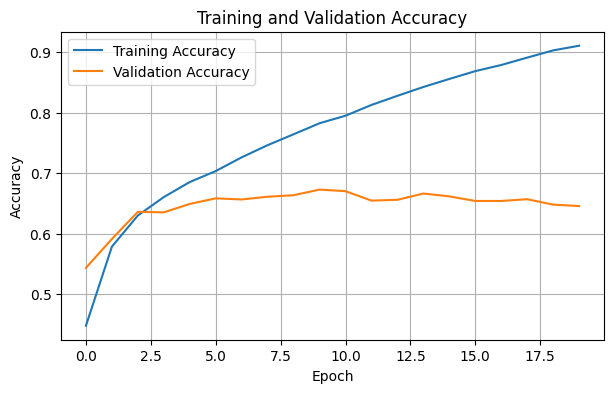

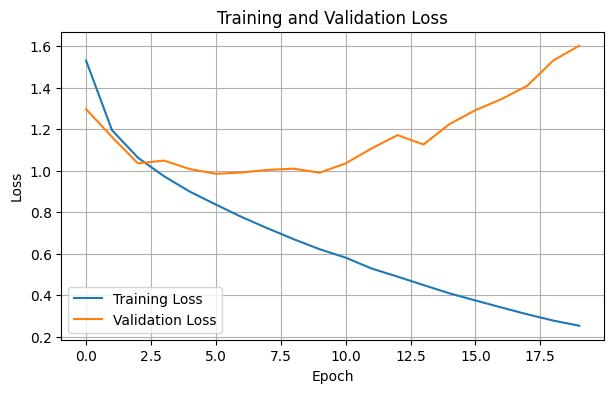

In [ ]:
# ============================
# ACCURACY AND LOSS PLOTS
# ============================


plt.figure(figsize=(7,4))

plt.plot(
    history.history['accuracy'],
    label="Training Accuracy"
)

plt.plot(
    history.history['val_accuracy'],
    label="Validation Accuracy"
)


plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()
plt.show()



plt.figure(figsize=(7,4))


plt.plot(
    history.history['loss'],
    label="Training Loss"
)


plt.plot(
    history.history['val_loss'],
    label="Validation Loss"
)


plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()

plt.show()

In [ ]:
# ============================
# TASK 7: MODEL EVALUATION
# ============================

import numpy as np
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)


# Test Accuracy

test_loss, test_accuracy = cnn_model.evaluate(
    X_test,
    y_test
)


print(
    "Testing Accuracy:",
    test_accuracy
)



# Prediction

y_pred = cnn_model.predict(X_test)


y_pred_classes = np.argmax(
    y_pred,
    axis=1
)


y_true = y_test.flatten()



# Metrics

precision = precision_score(
    y_true,
    y_pred_classes,
    average='weighted'
)


recall = recall_score(
    y_true,
    y_pred_classes,
    average='weighted'
)


f1 = f1_score(
    y_true,
    y_pred_classes,
    average='weighted'
)



print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)



# Classification Report

print(
    classification_report(
        y_true,
        y_pred_classes,
        target_names=class_names
    )
)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6399 - loss: 1.6616
Testing Accuracy: 0.6399000287055969
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
Precision: 0.6504317834673778
Recall: 0.6399
F1 Score: 0.6429036087438682
              precision    recall  f1-score   support

    airplane       0.68      0.69      0.69      1000
  automobile       0.73      0.78      0.76      1000
        bird       0.50      0.56      0.53      1000
         cat       0.41      0.53      0.46      1000
        deer       0.59      0.57      0.58      1000
         dog       0.56      0.47      0.51      1000
        frog       0.73      0.72      0.72      1000
       horse       0.76      0.65      0.70      1000
        ship       0.77      0.74      0.75      1000
       truck       0.77      0.68      0.72      1000

    accuracy                           0.64     10000
   macro avg       0.65      0.64      0.64     10000
weighted avg       0.65      0.64      0.64     10000



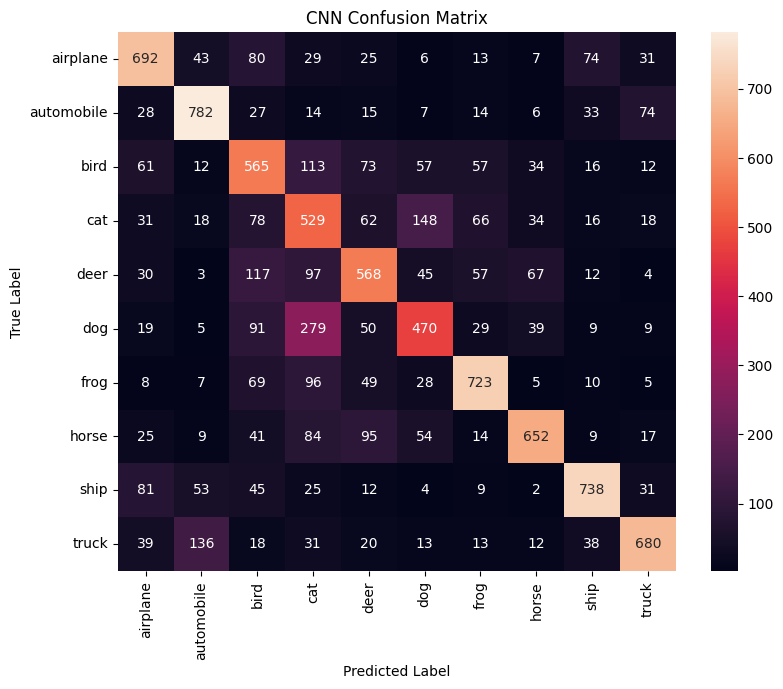

In [ ]:
# ============================
# CONFUSION MATRIX
# ============================

import seaborn as sns
import matplotlib.pyplot as plt


cm = confusion_matrix(
    y_true,
    y_pred_classes
)


plt.figure(figsize=(9,7))


sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=class_names,
    yticklabels=class_names
)


plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("CNN Confusion Matrix")

plt.show()
